In [1]:
import pandas as pd
import numpy as np
import os

os.makedirs('../data/processed', exist_ok=True)

# Load the clean data
df = pd.read_csv('../data/cleaned/master_data.csv', index_col=0, parse_dates=True)
print(f"Loaded {len(df)} rows.")

Loaded 4125 rows.


<Axes: title={'center': 'Estimated Brass Melt Cost (₹/kg)'}, xlabel='Date'>

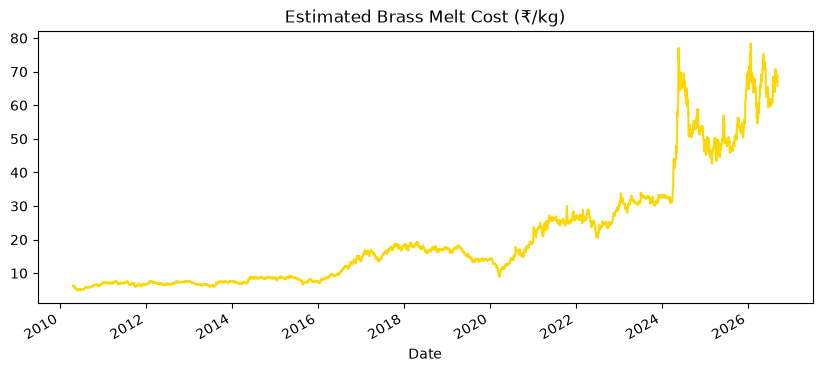

In [3]:
LB_TO_KG = 0.453592

# 1. Convert Copper to INR/kg
df['Copper_INR_kg'] = (df['copper_Close'] / 100 / LB_TO_KG) * df['usdinr_Close']

# 2. Zinc Proxy (Hindustan Zinc is a stock, so we use a scaling factor to approximate the raw material price)
# In a real foundry, you would calibrate this 0.25 number against their actual invoices.
df['Zinc_INR_kg'] = df['zinc_proxy_Close'] * 0.25 

# 3. The Brass Formula: 60% Cu + 40% Zn
df['Brass_Cost'] = (0.60 * df['Copper_INR_kg']) + (0.40 * df['Zinc_INR_kg'])

# Let's see what it looks like
df['Brass_Cost'].plot(figsize=(10,4), title='Estimated Brass Melt Cost (₹/kg)', color='gold')

In [4]:
# Daily Returns (Did price go up or down today?)
df['Daily_Return'] = df['Brass_Cost'].pct_change()

# Simple Moving Averages (SMA) - captures short and medium trends
df['SMA_10'] = df['Brass_Cost'].rolling(window=10).mean()
df['SMA_30'] = df['Brass_Cost'].rolling(window=30).mean()

# Volatility (Risk) - How wild are the price swings over the last 14 days?
df['Volatility_14d'] = df['Daily_Return'].rolling(window=14).std()

print("Features created!")

Features created!


In [5]:
# 1. What is the price 5 days from now? (We use shift(-5) to look into the future)
df['Future_Price_5d'] = df['Brass_Cost'].shift(-5)

# 2. Did the future price go up? (1 if True, 0 if False)
df['Target_Direction'] = (df['Future_Price_5d'] > df['Brass_Cost']).astype(int)

# Drop any rows with missing values that we just created
df = df.dropna()

print(f"Final shape for Machine Learning: {df.shape}")
df[['Brass_Cost', 'Future_Price_5d', 'Target_Direction']].head()

Final shape for Machine Learning: (4091, 14)


,Brass_Cost,Future_Price_5d,Target_Direction
Date,,,
2010-06-01,5.114208,4.864652,0
2010-06-02,5.069890,4.976142,0
2010-06-03,5.123958,5.054046,0
2010-06-04,5.037003,5.083472,1
2010-06-07,4.920471,5.190213,1


In [6]:
# Save the final features dataset
df.to_csv('../data/processed/ml_features.csv')
print("Saved successfully! Ready for Model Training.")

Saved successfully! Ready for Model Training.
